# Implementação de Modelos de Regressão e Classificação

<hr>

|Nome|RA|
|---|---|
| Gustavo Garabetti Munhoz | 10409258 |
| João Pedro Rodrigues Vieira | 10403595 |

## Setup inicial

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# por qualquer razão, estamos obtendo erro ao importar root_mean_squared_error pelo sklearn.metrics

Dataset a ser utilizado [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data)

In [ ]:
df = pd.read_csv("../dataset/dataset.csv")

## Compreensão dos dados

In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Tratamento do dataset

Como é possível perceber, a coluna `Unnamed: 0` não é relevante para a análise, por representar uma coleção de índices. Então, ela será removida.

In [7]:
df = df.drop(columns=['Unnamed: 0'])

In [8]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Análise de correlação

In [9]:
numeric_var_df = df.select_dtypes(include=["number"])
numeric_var_df.head()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


In [10]:
numeric_var_df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [11]:
pearson_corr_df = numeric_var_df.corr(method="pearson")
pearson_corr_df

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007101,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.007101,1.000000,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
danceability,0.035448,-0.073426,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,0.001056,0.058523,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.003853,0.008114,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,0.050423,-0.003470,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,-0.013931,-0.035556,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.044927,-0.062600,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011
acousticness,-0.025472,-0.103788,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138
instrumentalness,-0.095139,0.124371,-0.185606,-0.181879,-0.006823,-0.433477,-0.049955,-0.089616,0.104027,1.000000,-0.079893,-0.324312,-0.050330,-0.082580


In [12]:
# Retorna uma matriz com o a porção triangular superior com valores iguais a True e a inferior, False.
# Ref:
# https://numpy.org/doc/2.1/reference/generated/numpy.triu.html
# https://numpy.org/devdocs/reference/generated/numpy.ones_like.html
mask = np.triu(np.ones_like(pearson_corr_df, dtype=bool))

# Aplica a máscara na matriz de correlação, anulando (NaN) valores em posições marcadas como True.
# Ou seja, es removendo a porção triangular superior da matriz e mantendo apenas a inferior.
# O stack vem para transformar a matrix resultante em uma única Series, uma grande coluna indexada com
# os pares de variáveis e com os valores representando a correlação entre elas.
# Ou seja, temos várias linhas com suas respectivas correlações.
# 
# Ref:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mask.html
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.stack.html
corr_pairs = pearson_corr_df.mask(mask).stack()

# Por fim, esta linha pega os valores absolutos das correlações, os ordena e retorna os índices,
# que refletirão esta ordenação. O reindex nada mais faz do que reorganizar o dataframe com base
# nestes índices ordenados. Assim, temos as maiores (ou "melhores") correlações, independentemente
# de serem positivas ou negativas
top_correlations = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)
top_correlations.head(10)


loudness          energy              0.761690
acousticness      energy             -0.733906
                  loudness           -0.589803
valence           danceability        0.477341
instrumentalness  loudness           -0.433477
valence           instrumentalness   -0.324312
                  loudness            0.279848
loudness          danceability        0.259077
valence           energy              0.258934
tempo             energy              0.247851
dtype: float64

Com este resultado,é possível selecionar um par de variáveis, cuja a correlação seja positiva ou negativa, para treinar um modelo de regressão linear. Antes disso, no entanto, é válido verificar quais destas variáveis seguem uma distribuição normal e quais destas sofrem maior ou menor interferência de outliers.

In [13]:
numeric_var_df.skew()

popularity           0.046403
duration_ms         11.195181
danceability        -0.399497
energy              -0.597001
key                 -0.008500
loudness            -2.006542
mode                -0.572300
speechiness          4.647516
acousticness         0.727295
instrumentalness     1.734406
liveness             2.105738
valence              0.115078
tempo                0.232295
time_signature      -4.098317
dtype: float64

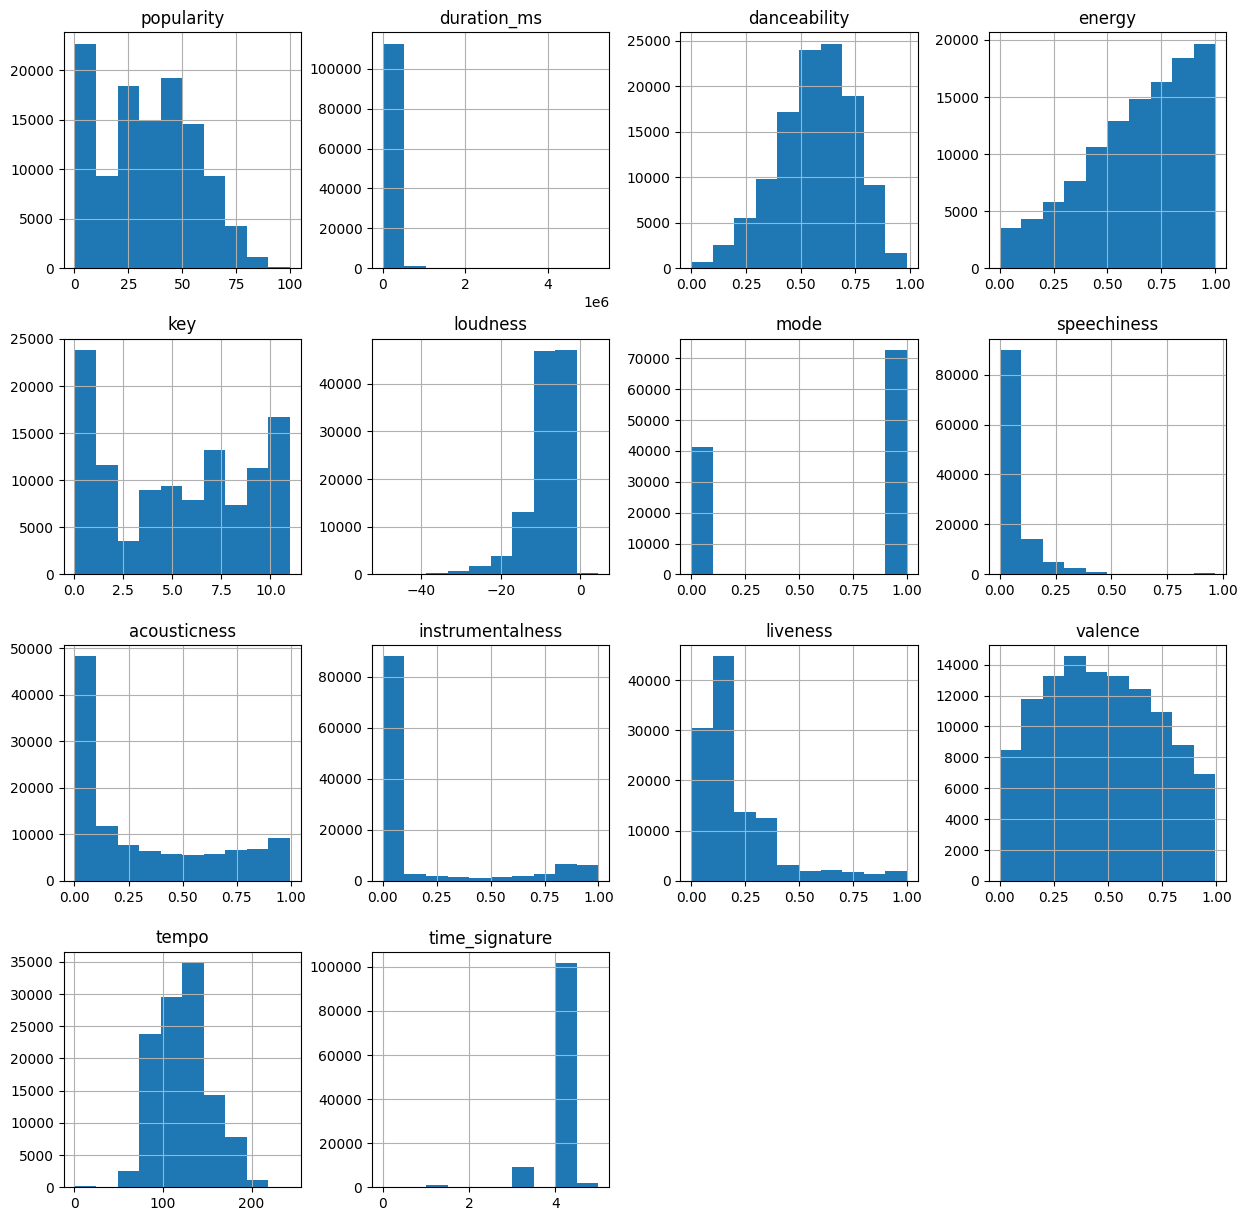

In [14]:
numeric_var_df.hist(figsize=(15, 15)).all()
plt.show()

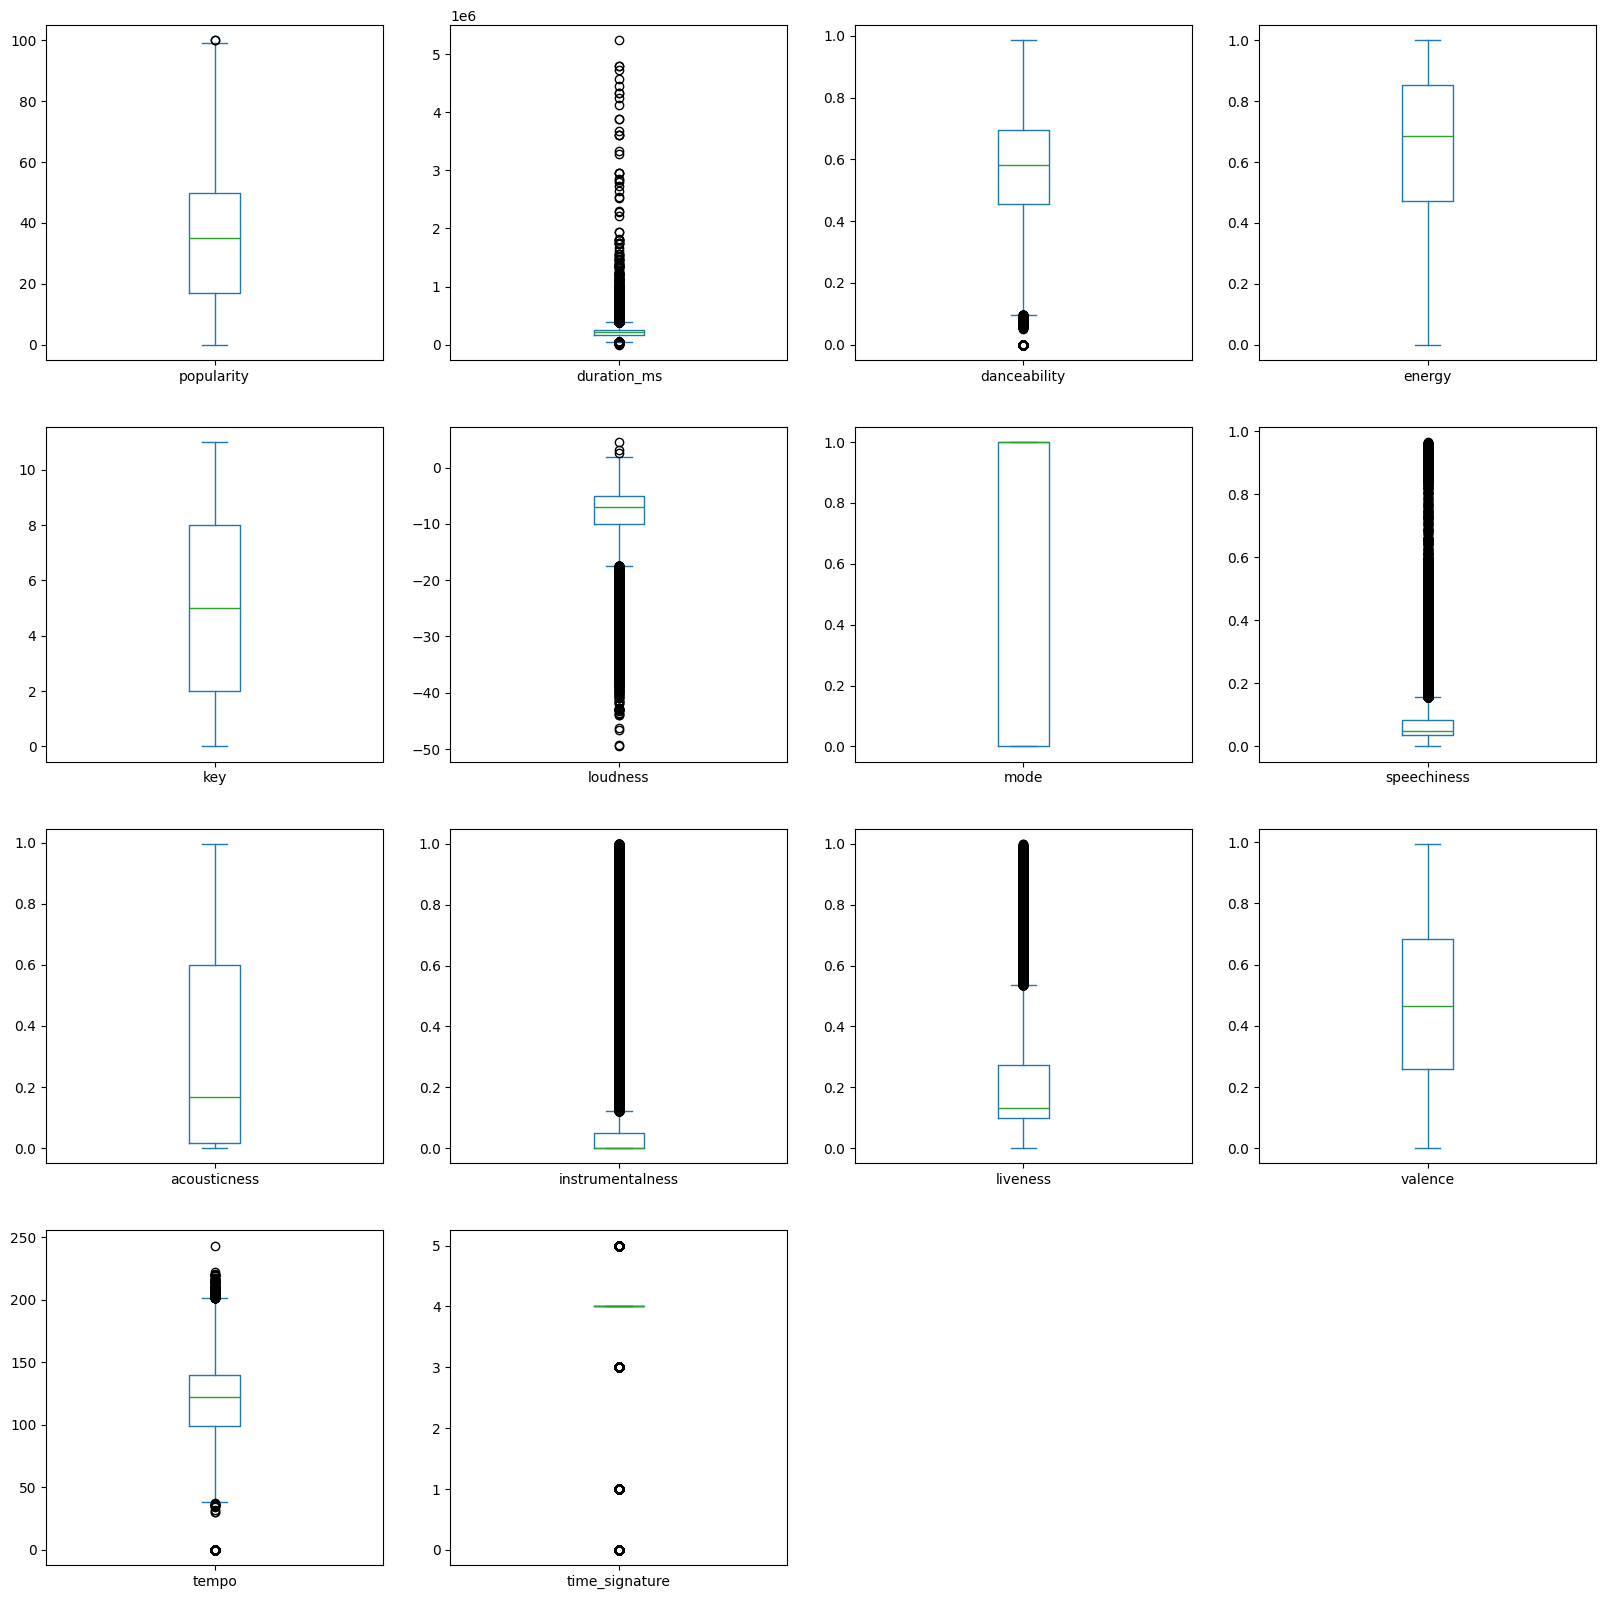

In [15]:
numeric_var_df.plot(kind="box", subplots=True, sharex=False, sharey=False, layout=(4, 4), figsize=(20, 20))
plt.show()

Com base nas relações apresentadas, a escolha entre as variáveis `valence` (o grau de "positividade" da música) e `danceability` (o quão dançável uma música é) parece ser apropriada. Ambas possuem uma correlação positiva moderada, seguem uma distribuição normal e somente `danceability` sofre, de acordo com o `boxplot`, com a presença de outliers. Outro fator importante é que ambas as variáveis seguem a mesma escala, de 0.0 a 1.0.

Pois bem, além disso, vale mencionar que não há uma relação de multicolinearidade entre estas duas variáveis. Isto porque a positividade de uma música nada diz sobre o quanto a mesma favorece desenvolver passos de dança. Estilos de dança como o tango e o bolero são conhecidos por serem dramáticos e incorporarem melodias consideradas "lentas", menos "positivas", mas que são ricas em repertório de dança.

## Treinamento do modelo de regressão linear

### Preparando variáveis para treinar o modelo

In [16]:
seed = 34
test_size = 0.3
x = numeric_var_df["valence"]
x = x.values.reshape(-1, 1)
y = numeric_var_df["danceability"]

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=seed)

### Treinamento do modelo

In [18]:
model = LinearRegression()

In [19]:
result = model.fit(x_train, y_train)

### Analisando Performance

In [20]:
y_pred = model.predict(x_test)
print("Previsões no teste: ", y_pred)

Previsões no teste:  [0.56723004 0.71283558 0.51390521 ... 0.69750868 0.66525833 0.49762038]


In [21]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2: {r2}")
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

R2: 0.22875092466316416
MSE: 0.023215296609456648
MAE: 0.12249781794591923
RMSE: 0.15236566742365765


Embora, segundo a métrica R<sup>2</sup>, utilizar `valence` permite explicar 22,87% dos dados de `danceability`, todas as medidas de erro são baixas, o que indica que o modelo alcançou um certo limite dentro de suas capacidades. Neste sentido, poderia ser interessante avaliar a possibilidade de adicionar mais variáveis independentes que tenham algum efeito explicativo substancial sobre a dependente.

## E quanto às variáveis categóricas?

Primeiramente, vamos analisar quais são as variáveis categóricas e como estas estão distribuídas ao longo do dataset.

In [22]:
categorical_var_df = df.select_dtypes(include=["object", "bool"])
categorical_var_df.head()

,track_id,artists,album_name,track_name,explicit,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,False,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,False,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,False,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,False,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,False,acoustic


Bom, de imediato, já é possível remover `track_id` do dataframe de variáveis categóricas.

In [23]:
categorical_var_df = categorical_var_df.drop(columns=["track_id"])
categorical_var_df.head()

,artists,album_name,track_name,explicit,track_genre
0,Gen Hoshino,Comedy,Comedy,False,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,False,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,False,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,False,acoustic
4,Chord Overstreet,Hold On,Hold On,False,acoustic


In [24]:
categorical_var_df.shape

(114000, 5)

In [25]:
categorical_var_df.nunique()

artists        31437
album_name     46589
track_name     73608
explicit           2
track_genre      114
dtype: int64

In [26]:
categorical_var_df.describe()

,artists,album_name,track_name,explicit,track_genre
count,113999,113999,113999,114000,114000
unique,31437,46589,73608,2,114
top,The Beatles,Alternative Christmas 2022,Run Rudolph Run,False,acoustic
freq,279,195,151,104253,1000


### Qual variável categórica seria interessante para previsão?

Em um contexto comercial, as recomendações realizadas em uma aplicação musical são peça chave para a manutenção do usuário na plataforma. Neste sentido, prever o gênero de uma próxima música pode ser o primeiro passo para uma "boa" recomendação, isto é, a que ajude a alcançar o objetivo, que, neste contexto, é manter o usuário na aplicação por mais tempo. Assim, é de se pensar que prever a variável `track_genre` seja um bom começo.

In [27]:
categorical_var_df["track_genre"].value_counts()

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
                     ... 
folk                 1000
emo                  1000
electronic           1000
electro              1000
world-music          1000
Name: count, Length: 114, dtype: int64

São, ao todo, 114 categorias, cada qual com 1000 observações. Para aplicar estas variáveis em um modelo de regressão, poderia ser feita a conversão destes valores em variáveis numéricas, algo simples como definir acoustic como 0, punk-rock como 1 e assim por diante (o mais adequado seria numerar de acordo com uma ordem alfabética). O importante - é claro - é manter guardada a definição original, para não perder sentido quando fizermos uma análise da performance do modelo.